In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.regression import RandomForestRegressionModel

spark = SparkSession.builder \
    .appName("SCNE Model Evaluation") \
    .master("local[*]") \
    .getOrCreate()

DATA_PATH = r"D:\Big Data Programming Project\Final Assignment\data\processed\spark\scne_model_features"
MODEL_PATH = r"D:\Big Data Programming Project\Final Assignment\models\random_forest_delay_model"

model_df = spark.read.parquet(DATA_PATH)
rf_model = RandomForestRegressionModel.load(MODEL_PATH)

print("Rows:", model_df.count())
print("Random Forest model loaded successfully")

Rows: 308885
Random Forest model loaded successfully


In [2]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

train_df = model_df.filter(
    model_df.service_date.isin("2025-12-26", "2025-12-27")
)

test_df = model_df.filter(
    model_df.service_date == "2025-12-28"
)

route_indexer = StringIndexer(
    inputCol="published_line_name",
    outputCol="route_index",
    handleInvalid="keep"
)

tree_feature_columns = [
    "route_index",
    "direction_id",
    "stop_sequence",
    "hour",
    "minute",
    "day_of_week",
    "is_weekend",
    "is_public_holiday",
    "journey_progress",
    "previous_stop_delay",
    "rolling_previous_delay",
    "has_previous_delay"
]

assembler = VectorAssembler(
    inputCols=tree_feature_columns,
    outputCol="tree_features"
)

prep_pipeline = Pipeline(
    stages=[route_indexer, assembler]
)

prep_model = prep_pipeline.fit(train_df)

test_ready = prep_model.transform(test_df)

predictions = rf_model.transform(test_ready)

print("Test rows:", predictions.count())

predictions.select(
    "delay_seconds",
    "prediction"
).show(10)

Test rows: 106845
+-------------+-------------------+
|delay_seconds|         prediction|
+-------------+-------------------+
|       -132.0| -69.87062157736509|
|        -51.0| -6.417084496829219|
|       -111.0| -14.22420675666658|
|        -50.0|-42.184290123067385|
|        -29.0|-28.877903031144065|
|        -49.0| -33.22174846484879|
|       -109.0| -32.24195016721483|
|       -108.0| -59.73178062468653|
|       -108.0| -63.83295307856165|
|        -47.0| -64.45332502648665|
+-------------+-------------------+
only showing top 10 rows



In [3]:
from pyspark.ml.evaluation import RegressionEvaluator

mae = RegressionEvaluator(
    labelCol="delay_seconds",
    predictionCol="prediction",
    metricName="mae"
).evaluate(predictions)

rmse = RegressionEvaluator(
    labelCol="delay_seconds",
    predictionCol="prediction",
    metricName="rmse"
).evaluate(predictions)

r2 = RegressionEvaluator(
    labelCol="delay_seconds",
    predictionCol="prediction",
    metricName="r2"
).evaluate(predictions)

print("Random Forest Test Performance")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

Random Forest Test Performance
MAE: 61.95
RMSE: 137.57
R²: 0.7548


In [4]:
from pyspark.sql import functions as F

evaluation_df = (
    predictions
    .withColumn(
        "error",
        F.col("delay_seconds") - F.col("prediction")
    )
    .withColumn(
        "absolute_error",
        F.abs(F.col("error"))
    )
)

evaluation_df.select(
    "delay_seconds",
    "prediction",
    "error",
    "absolute_error"
).show(10)

+-------------+-------------------+--------------------+-------------------+
|delay_seconds|         prediction|               error|     absolute_error|
+-------------+-------------------+--------------------+-------------------+
|       -132.0| -69.87062157736509| -62.129378422634915| 62.129378422634915|
|        -51.0| -6.417084496829219|  -44.58291550317078|  44.58291550317078|
|       -111.0| -14.22420675666658|  -96.77579324333342|  96.77579324333342|
|        -50.0|-42.184290123067385|  -7.815709876932615|  7.815709876932615|
|        -29.0|-28.877903031144065|-0.12209696885593502|0.12209696885593502|
|        -49.0| -33.22174846484879| -15.778251535151213| 15.778251535151213|
|       -109.0| -32.24195016721483|  -76.75804983278516|  76.75804983278516|
|       -108.0| -59.73178062468653|  -48.26821937531347|  48.26821937531347|
|       -108.0| -63.83295307856165|  -44.16704692143835|  44.16704692143835|
|        -47.0| -64.45332502648665|  17.453325026486652| 17.453325026486652|

In [5]:
error_summary = evaluation_df.select(
    F.round(F.avg("error"), 2).alias("mean_error"),
    F.round(F.avg("absolute_error"), 2).alias("mean_absolute_error"),
    F.round(F.stddev("error"), 2).alias("error_stddev"),
    F.round(F.max("absolute_error"), 2).alias("maximum_absolute_error")
)

error_summary.show()

+----------+-------------------+------------+----------------------+
|mean_error|mean_absolute_error|error_stddev|maximum_absolute_error|
+----------+-------------------+------------+----------------------+
|      3.55|              61.95|      137.53|               1823.22|
+----------+-------------------+------------+----------------------+



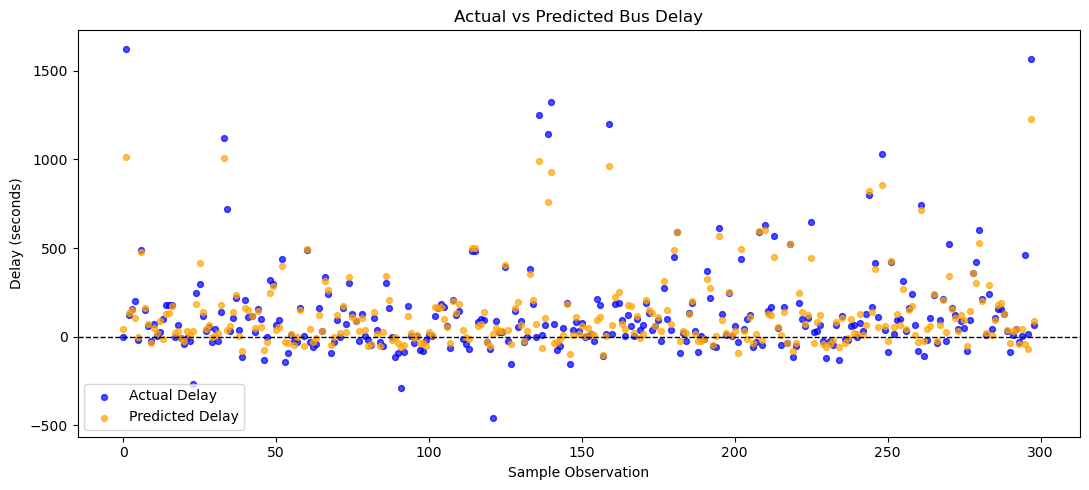

In [7]:
plot_sample = (
    evaluation_df
    .select("delay_seconds", "prediction")
    .sample(False, 0.003, seed=42)
    .limit(500)
    .toPandas()
    .reset_index(drop=True)
)

plt.figure(figsize=(11, 5))

plt.scatter(
    plot_sample.index,
    plot_sample["delay_seconds"],
    s=18,
    alpha=0.7,
    color="blue",
    label="Actual Delay"
)

plt.scatter(
    plot_sample.index,
    plot_sample["prediction"],
    s=18,
    alpha=0.7,
    color="orange",
    label="Predicted Delay"
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Actual vs Predicted Bus Delay")
plt.xlabel("Sample Observation")
plt.ylabel("Delay (seconds)")
plt.legend()

plt.tight_layout()
plt.show()

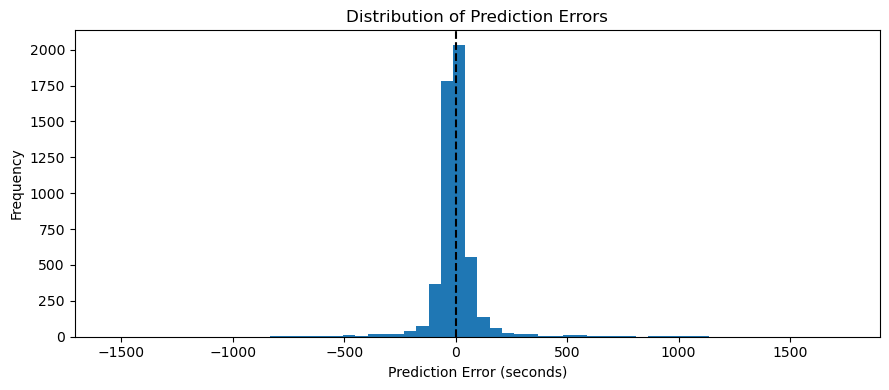

In [8]:
residual_sample = (
    evaluation_df
    .select("error")
    .sample(False, 0.05, seed=42)
    .toPandas()
)

plt.figure(figsize=(9, 4))

plt.hist(
    residual_sample["error"],
    bins=60
)

plt.axvline(0, color="black", linestyle="--")

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (seconds)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [10]:
largest_errors = (
    evaluation_df
    .select(
        "service_date",
        "published_line_name",
        "stop_id",
        "delay_seconds",
        "prediction",
        "absolute_error"
    )
    .orderBy(F.col("absolute_error").desc())
)

largest_errors.show(15, truncate=False)

+------------+-------------------+------------+-------------+-------------------+------------------+
|service_date|published_line_name|stop_id     |delay_seconds|prediction         |absolute_error    |
+------------+-------------------+------------+-------------+-------------------+------------------+
|2025-12-28  |4                  |410000029206|1768.0       |-55.21689865895237 |1823.2168986589525|
|2025-12-28  |X78                |410000008071|1798.0       |39.182424535589654 |1758.8175754644103|
|2025-12-28  |18                 |410000042042|1798.0       |47.8032777753372   |1750.1967222246628|
|2025-12-28  |39                 |079073190A  |1678.0       |-68.87647868031522 |1746.8764786803151|
|2025-12-28  |18                 |410000042C04|1728.0       |-15.555950927698637|1743.5559509276986|
|2025-12-28  |39                 |079073190A  |1691.0       |-48.75099401048082 |1739.7509940104808|
|2025-12-28  |18                 |410000042042|1776.0       |39.39631631225895  |1736.60368

In [11]:
error_by_group = (
    evaluation_df
    .withColumn(
        "delay_group",
        F.when(F.abs("delay_seconds") <= 300, "Within 5 min")
         .when(F.abs("delay_seconds") <= 900, "5 to 15 min")
         .otherwise("Over 15 min")
    )
    .groupBy("delay_group")
    .agg(
        F.count("*").alias("observations"),
        F.round(F.avg("absolute_error"), 2).alias("mean_absolute_error")
    )
    .orderBy("mean_absolute_error")
)

error_by_group.show()

+------------+------------+-------------------+
| delay_group|observations|mean_absolute_error|
+------------+------------+-------------------+
|Within 5 min|       90045|              42.77|
| 5 to 15 min|       13525|             101.46|
| Over 15 min|        3275|             426.31|
+------------+------------+-------------------+



In [12]:
comparison_data = [
    ("Linear Regression", 93.34, 149.36, 0.7110),
    ("Decision Tree", 66.79, 158.23, 0.6756),
    ("Random Forest", 61.95, 137.57, 0.7548),
    ("Gradient-Boosted Tree", 66.55, 152.51, 0.6987)
]

comparison_df = spark.createDataFrame(
    comparison_data,
    ["Model", "MAE", "RMSE", "R2"]
)

comparison_df.orderBy("RMSE").show(truncate=False)

+---------------------+-----+------+------+
|Model                |MAE  |RMSE  |R2    |
+---------------------+-----+------+------+
|Random Forest        |61.95|137.57|0.7548|
|Linear Regression    |93.34|149.36|0.711 |
|Gradient-Boosted Tree|66.55|152.51|0.6987|
|Decision Tree        |66.79|158.23|0.6756|
+---------------------+-----+------+------+



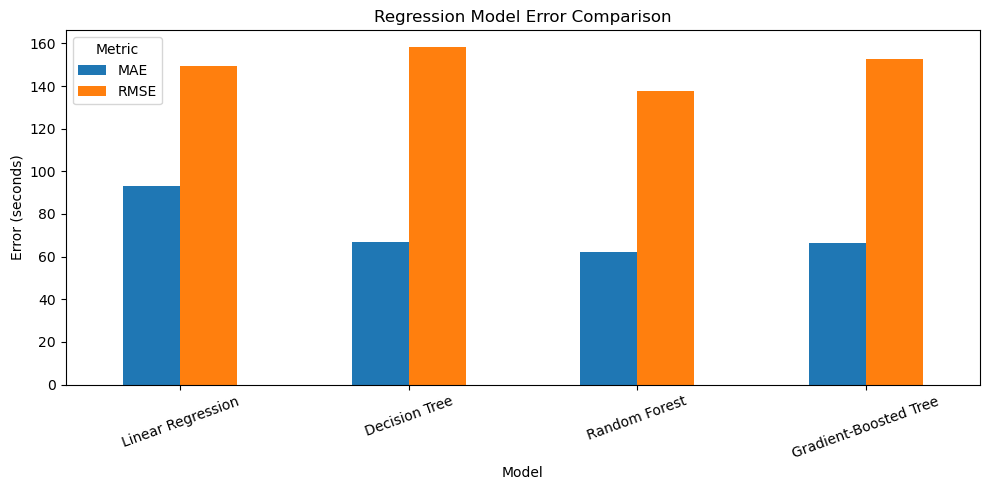

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient-Boosted Tree"
    ],
    "MAE": [93.34, 66.79, 61.95, 66.55],
    "RMSE": [149.36, 158.23, 137.57, 152.51]
})

model_results.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Regression Model Error Comparison")
plt.xlabel("Model")
plt.ylabel("Error (seconds)")
plt.xticks(rotation=20)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

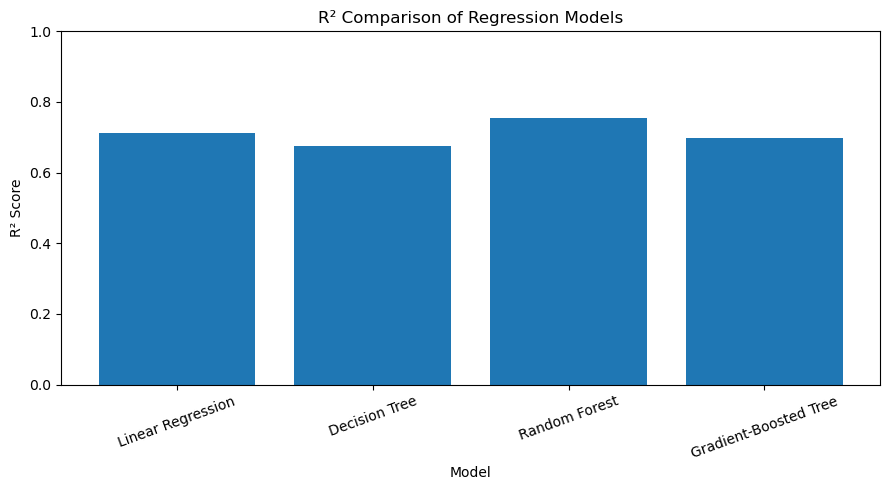

In [14]:
r2_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient-Boosted Tree"
    ],
    "R2": [0.7110, 0.6756, 0.7548, 0.6987]
})

plt.figure(figsize=(9, 5))

plt.bar(
    r2_results["Model"],
    r2_results["R2"]
)

plt.title("R² Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

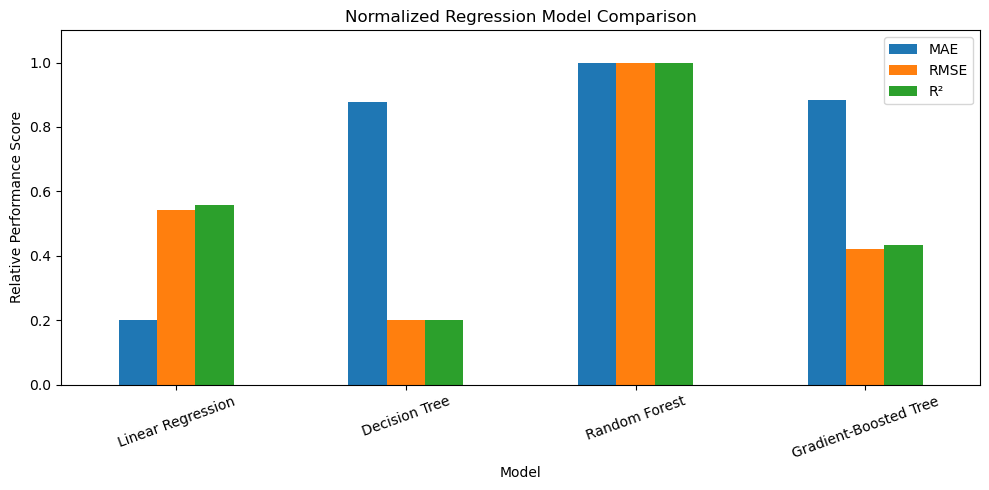

In [16]:
comparison_plot = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient-Boosted Tree"
    ],
    "MAE": [93.34, 66.79, 61.95, 66.55],
    "RMSE": [149.36, 158.23, 137.57, 152.51],
    "R2": [0.7110, 0.6756, 0.7548, 0.6987]
})

# Scale scores between 0.2 and 1.0
def scale_score(series, lower_is_better=False):
    if lower_is_better:
        score = (series.max() - series) / (series.max() - series.min())
    else:
        score = (series - series.min()) / (series.max() - series.min())

    return 0.2 + (0.8 * score)

comparison_plot["MAE_score"] = scale_score(
    comparison_plot["MAE"],
    lower_is_better=True
)

comparison_plot["RMSE_score"] = scale_score(
    comparison_plot["RMSE"],
    lower_is_better=True
)

comparison_plot["R2_score"] = scale_score(
    comparison_plot["R2"]
)

comparison_plot.set_index("Model")[
    ["MAE_score", "RMSE_score", "R2_score"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Normalized Regression Model Comparison")
plt.xlabel("Model")
plt.ylabel("Relative Performance Score")
plt.ylim(0, 1.1)

plt.xticks(rotation=20)
plt.legend(["MAE", "RMSE", "R²"])

plt.tight_layout()
plt.show()